# Exercice 2. Entrainez un agent avec une Q-table (Q-Learning)
## Projet Eagle-1 · AstroDynamics · OpenClassrooms
**Auteur :** Rafael Cerezo Martin 

**Date :** Juin 2025

---

### Objectif
Implementer depuis zero le premier vrai algorithme d'apprentissage :

> **Q-Learning tabulaire sur FrozenLake-v1**

1. Preparer l'environnement et la Q-table
2. Implementer la boucle Q-Learning avec strategie epsilon-greedy
3. Evaluer l'agent entraine (taux de succes sur 100 episodes)
4. Visualiser : Q-table heatmap, courbes d'apprentissage, animation en temps reel

---
### [Cellule] Installation et chargement des modules core

In [1]:
# !pip install gymnasium stable-baselines3 -q

# ============================================================
# ENVIRONNEMENT — détection automatique Colab / local
# ============================================================
import sys                                     # gestion du chemin Python
import os                                      # opérations système
from pathlib import Path                       # chemins portables
from datetime import datetime                  # pour ajouter date dans les noms de fichiers

print(sys.version)

try:
    import google.colab                        # disponible uniquement sur Colab
    BASE = Path(
        '/content/drive/MyDrive/OpenClassrooms'
        '/M11_Entrainez_votre_agent_RL/m11_ocr'
    )
except ImportError:
    BASE = Path().resolve().parent             # notebooks/ → m11_ocr/

CORE    = BASE / 'core'                        # modules utilitaires du projet
MODELS  = BASE / 'models'                      # modèles entraînés sauvegardés
REPORTS = BASE / 'reports'                      # modèles entraînés sauvegardés
MODELS.mkdir(exist_ok=True)                   # créer si absent

sys.path.insert(0, str(CORE))                 # rendre les modules importables

# ── Chemins fichiers ──────────────────────────────────────────
# q_path = '/content/drive/MyDrive/OpenClassrooms/M11_Entrainez_votre_agent_RL/m11_ocr/q_table_frozenlake.pkl'


# ============================================================
# MODULES CORE DU PROJET
# ============================================================
from env_utils import make_env                 # création d'environnements Gym
from env_utils import inspect_env              # inspection des espaces
from env_utils import run_n_random_episodes    # épisodes politique aléatoire

from metrics   import compute_stats            # statistiques descriptives
from metrics   import print_stats              # affichage formaté des stats
from metrics   import moving_average           # moyenne glissante
from metrics   import success_rate             # taux de réussite

from viz_utils import plot_episode_metrics     # courbes récompense/pas
from viz_utils import plot_reward_distribution # histogramme des récompenses
from viz_utils import animate_episode_with_metrics  # animation avec métriques
from viz_utils import show_env_frame           # affichage frame statique
from viz_utils import plot_q_directional_map   # carte directionnelle Q-table

# ============================================================
# BIBLIOTHÈQUES SCIENTIFIQUES
# ============================================================
import numpy              as np               # calcul vectoriel et matriciel
import pickle                                 # sérialisation Q-table
import random                                 # génération aléatoire Python ← AÑADIR

# ============================================================
# ENVIRONNEMENTS DE SIMULATION — Gymnasium
# ============================================================
import gymnasium          as gym              # environnements RL standardisés

# ============================================================
# VISUALISATION — Matplotlib
# ============================================================
%matplotlib inline
import matplotlib                             # configuration du backend
import matplotlib.pyplot   as plt             # tracé de graphiques
import matplotlib.patches  as patches         # formes géométriques (FancyBox…)
import matplotlib.animation as animation      # animations frame par frame
import matplotlib.gridspec  as gridspec       # mise en page multi-panneaux

# ============================================================
# UTILITAIRES PYTHON
# ============================================================
from collections      import deque            # buffer circulaire
from IPython.display  import HTML, display    # affichage HTML dans le notebook

# ============================================================
# VÉRIFICATION DE L'ENVIRONNEMENT
# ============================================================
SEED      = 42                                # graine reproductibilité
SEED_EVAL = 99                                # graine évaluation distincte
WINDOW    = 50                                # fenêtre moyenne glissante

IS_SLIPPERY = False   # True = sol glissant (stochastique)
                      # False = déterministe (plus facile)

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022

print("\n============================================================")
print("VÉRIFICATION DE L'ENVIRONNEMENT")
print("============================================================")
print(f"  Gymnasium...........: {gym.__version__}")
print(f"  NumPy...............: {np.__version__}")
print(f"  GPU disponible......: False  (non requis pour Q-Learning)")
print(f"  Backend matplotlib..: {matplotlib.get_backend()}")
print("============================================================")
print(f"  BASE................: {BASE}")
print(f"  CORE................: {CORE}")
print(f"  CORE existe.........: {CORE.exists()}")
print(f"  DATE................: {ts}")
print("============================================================")

# ── Test rapide de l'environnement ───────────────────────────
_env = make_env('FrozenLake-v1', seed=SEED)
print(f"  FrozenLake-v1.......: OK"
      f"  n_states={_env.observation_space.n}"
      f"  n_actions={_env.action_space.n}")
_env.close()
print("============================================================")

3.12.12 (main, Jan 14 2026, 19:30:21) [MSC v.1944 64 bit (AMD64)]

VÉRIFICATION DE L'ENVIRONNEMENT
  Gymnasium...........: 1.3.0
  NumPy...............: 2.4.6
  GPU disponible......: False  (non requis pour Q-Learning)
  Backend matplotlib..: inline
  BASE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr
  CORE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\core
  CORE existe.........: True
  DATE................: 260620_113758
  FrozenLake-v1.......: OK  n_states=16  n_actions=4


---
## Etape 1. Preparer l'environnement et la Q-table

FrozenLake-v1 a un espace **discret fini** — ideal pour la Q-table.
La Q-table est une matrice `(n_etats x n_actions)` initialisee a zero.

In [2]:
# Creer l'environnement FrozenLake-v1
#env = make_env('FrozenLake-v1', seed=42)
env = make_env('FrozenLake-v1', is_slippery=IS_SLIPPERY, seed=42)

# Inspecter les espaces
inspect_env(env)

# Dimensions de la Q-table
n_states  = env.observation_space.n   # 16 etats (grille 4x4)
n_actions = env.action_space.n        # 4 actions (←↓→↑)

# Initialiser la Q-table avec des zeros
q_table = np.zeros((n_states, n_actions))

print('=' * 50)
print('Q-TABLE INITIALISEE')
print('=' * 50)
print(f'  Shape................: {q_table.shape}')
print(f'  N etats..............: {n_states}')
print(f'  N actions............: {n_actions}')
print(f'  Valeurs initiales....: {q_table.sum():.1f}  (tout a zero)')
print()
print('Q-table (16 etats x 4 actions) :')
print(q_table)

env.close()

RAPPORT D INSPECTION DE L ENVIRONNEMENT

-- ESPACE D OBSERVATION -------------------------
  Type................: Discrete
  N etats.............: 16
  Exemple aleatoire...: 6

-- ESPACE D ACTION --------------------------------
  Type................: Discrete
  N actions...........: 4
  Actions dispo.......: [0, 1, 2, 3]
  Exemple aleatoire...: 0
Q-TABLE INITIALISEE
  Shape................: (16, 4)
  N etats..............: 16
  N actions............: 4
  Valeurs initiales....: 0.0  (tout a zero)

Q-table (16 etats x 4 actions) :
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Interpretation. Q-table initiale

La Q-table est une matrice `(16, 4)` entierement a zero.
Chaque cellule `Q[s, a]` representera la **valeur esperee** de prendre
l'action `a` depuis l'etat `s` en suivant la politique optimale.

| Index | Action | Direction |
|-------|--------|-----------|
| 0 | LEFT | ← gauche |
| 1 | DOWN | ↓ bas |
| 2 | RIGHT | → droite |
| 3 | UP | ↑ haut |

---
## Etape 2. Boucle Q-Learning avec strategie epsilon-greedy

### Equation de Bellman (mise a jour Q-Learning)

```
Q(s,a) <- Q(s,a) + alpha * [R + gamma * max_a' Q(s',a') - Q(s,a)]
```

- `alpha` (α) : taux d'apprentissage — vitesse de mise a jour
- `gamma` (γ) : facteur de discount — importance du futur
- `epsilon` (ε) : probabilite d'exploration aleatoire (decroit dans le temps)
- `R + gamma * max Q(s',a')` : cible TD (valeur estimee de la meilleure action suivante)
- `max Q(s',a') - Q(s,a)` : erreur TD (TD error)

### [Cellule] 🛠️ Hyperparametres

In [3]:
# ============================================================
# HYPERPARAMETRES
# ============================================================
# N_EPISODES  = 10_000  # nombre d'episodes d'entrainement
# ALPHA       = 0.8     # taux d'apprentissage
# GAMMA       = 0.95    # facteur de discount
# EPSILON     = 1.0     # exploration initiale (100%)
# EPSILON_MIN = 0.01    # exploration minimale
# EPSILON_DEC = 0.001   # decrement par episode


# N_EPISODES  = 10_000
# ALPHA       = 0.1     # Manténlo bajo para cuando pruebes con resbalamiento
# GAMMA       = 0.95
# EPSILON     = 1.0
# EPSILON_MIN = 0.01
# EPSILON_DEC = 0.9995  # <<--- CAMBIA ESTE VALOR (Antes tenías 0.001)


#N_EPISODES  = 2_000   # Bastan 2,000 episodios (¡no hacen falta 10,000!)
#ALPHA       = 0.8     # ¡SUBIR! En modo determinista, queremos aprender rápido de cada paso
#GAMMA       = 0.95
#GAMMA       = 0.95
#EPSILON     = 1.0
#EPSILON_MIN = 0.01
#EPSILON_DEC = 0.995   # Decaimiento más rápido para empezar a explotar antes

# ============================================================
# HYPERPARAMETRES (EQUILIBRIO TOTAL)
# ============================================================
N_EPISODES  = 10_000
ALPHA       = 0.5     # Bajamos a 0.5 para evitar oscilaciones agresivas
GAMMA       = 0.95
EPSILON     = 1.0
EPSILON_MIN = 0.01
EPSILON_DEC = 0.998   # <<-- Crucial: da margen a descubrir la meta de forma consistente

# ============================================================
# REINITIALISER LA Q-TABLE
# ============================================================
q_table     = np.zeros((n_states, n_actions))

### [Cellule] 🏋️‍♀️ Entrenaiment

In [4]:
# ============================================================
# BOUCLE D'ENTRAINEMENT Q-LEARNING
# ============================================================
from tqdm.notebook import tqdm

pbar = tqdm(range(N_EPISODES), desc="Q-Learning", unit="ep", colour="#534AB7")

# env       = make_env('FrozenLake-v1', seed=42)
env         = make_env('FrozenLake-v1', is_slippery=IS_SLIPPERY, seed=42)


# Listes pour suivre la progression
rewards_history  = []   # recompense par episode
steps_history    = []   # pas par episode
epsilon_history  = []   # valeur epsilon par episode
td_errors        = []   # erreur TD moyenne par episode

epsilon = EPSILON

action_arrows = {0: "◀", 1: "▼", 2: "▶", 3: "▲"}

# for episode in range(N_EPISODES):
for episode in pbar:
    # Reinitialiser l'environnement
    state, info  = env.reset(seed=42)
    total_reward = 0.0
    n_steps      = 0
    ep_td_errors = []
    terminated   = False
    truncated    = False

    while not (terminated or truncated):
        # Strategie epsilon-greedy
        if random.random() < epsilon:
            # Exploration : action aleatoire
            action = env.action_space.sample()
        else:
            # Exploitation : meilleure action connue
            action = np.argmax(q_table[state, :])

        # Afficher la flèche de l'action choisie (uniquement pour les épisodes suivis)
        # if episode <= N_EPISODES :   # episode == N_EPISODES - 1:
        #     print(action_arrows[action], end=" ")

        # Executer l'action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Mise a jour Q-Learning (equation de Bellman)
        # Q(s,a) <- Q(s,a)    + alpha * [R      + gamma  * max_a' Q(s',a') - Q(s,a)   ]
        #           ---------   -----    ------   -----    ---------------   ---------
        #           old_value   ALPHA    reward   GAMMA    next_max          old_value]
        #                                ---------------------------------   ---------
        #                                td_target                           old_value
        #           ---------   -----    ---------------------------------------------
        #           old_value   ALPHA                     td_error
        #
        # Q(s,a)
        old_value              = q_table[state, action]
        next_max               = np.max(q_table[next_state, :])
        td_target              = reward + GAMMA * next_max
        td_error               = td_target - old_value
        q_table[state, action] = old_value + ALPHA * td_error

        # Enregistrer l'erreur TD
        ep_td_errors.append(abs(td_error))

        total_reward += reward
        n_steps      += 1
        state         = next_state

    # Aficher le résultat final de la trajectoire dans la console
    #if episode <= N_EPISODES :   # episode == N_EPISODES - 1:
    #    if terminated and reward > 0:
    #        print(f"[G] {episode} (Goal - Succès)")
    #    elif terminated and reward == 0:
    #        print(f"[H] {episode} (Hole - Trou)")
    #    elif truncated:
    #        print(f"[T] {episode} (Truncated - Limite de pas)")

    # Decroissance epsilon (GLIE)
    # epsilon = max(EPSILON_MIN, epsilon - EPSILON_DEC)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DEC)

    # Enregistrer les metriques
    rewards_history.append(total_reward)
    steps_history.append(n_steps)
    epsilon_history.append(epsilon)
    td_errors.append(np.mean(ep_td_errors) if ep_td_errors else 0)

    if episode % 100 == 0:
        pbar.set_postfix({
            "ε"       : f"{epsilon:.3f}",
            "succès"  : f"{np.mean(rewards_history[-100:]):.1%}" if rewards_history else "0.0%",
            "td_err"  : f"{td_errors[-1]:.4f}"                   if td_errors       else "0.0"
        })

env.close()

print('=' * 50)
print('ENTRAINEMENT TERMINE')
print('=' * 50)
print(f'  Episodes.............: {N_EPISODES:,}')
print(f'  Epsilon final........: {epsilon:.4f}')
print(f'  Succes 1000 derniers.: {np.mean(rewards_history[-1000:]):.1%}')
q_sum = q_table.sum()
q_non_zero = np.count_nonzero(q_table)
statut = f"{q_non_zero} valeurs non-nulles" if q_non_zero > 0 else "⚠ table vide — entraînement sans apprentissage"
print(f'  Q-table sum..........: {q_sum:.4f}  ({statut})')

Q-Learning:   0%|          | 0/10000 [00:00<?, ?ep/s]

ENTRAINEMENT TERMINE
  Episodes.............: 10,000
  Epsilon final........: 0.0100
  Succes 1000 derniers.: 99.1%
  Q-table sum..........: 24.7768  (32 valeurs non-nulles)


In [5]:
# ── Après l'entrainement — AFICHER la Q-table ────────────
import pickle

print(f'  Sum..................: {q_table.sum():.4f}')
print(f'  Shape................: {q_table.shape}')
print(f'  Valeurs non-nulles...: {np.count_nonzero(q_table)}')

# ----------------------------------------------------------
# Affichage de la Q-table complète
# ----------------------------------------------------------
print()
print('  État  ◀ Gauche   ▼ Bas     ▶ Droite  ▲ Haut')
print('  ' + '─' * 46)
for s in range(q_table.shape[0]):
    best = np.argmax(q_table[s])
    action_arrows = {0: "◀", 1: "▼", 2: "▶", 3: "▲"}
    ligne = f'  [{s:02d}]  '
    for a in range(q_table.shape[1]):
        marqueur = '★' if a == best else ' '
        ligne += f'{q_table[s, a]:+.4f}{marqueur}  '
    print(ligne)

  Sum..................: 24.7768
  Shape................: (16, 4)
  Valeurs non-nulles...: 32

  État  ◀ Gauche   ▼ Bas     ▶ Droite  ▲ Haut
  ──────────────────────────────────────────────
  [00]  +0.7351   +0.7738★  +0.6983   +0.7351   
  [01]  +0.7351★  +0.0000   +0.6634   +0.6983   
  [02]  +0.6983★  +0.6095   +0.3543   +0.6143   
  [03]  +0.5134★  +0.0000   +0.0000   +0.0000   
  [04]  +0.7738   +0.8145★  +0.0000   +0.7351   
  [05]  +0.0000★  +0.0000   +0.0000   +0.0000   
  [06]  +0.0000   +0.0000   +0.0000   +0.6633★  
  [07]  +0.0000★  +0.0000   +0.0000   +0.0000   
  [08]  +0.8145   +0.0000   +0.8574★  +0.7738   
  [09]  +0.8145   +0.9025★  +0.9025   +0.0000   
  [10]  +0.8574   +0.9500★  +0.0000   +0.6237   
  [11]  +0.0000★  +0.0000   +0.0000   +0.0000   
  [12]  +0.0000★  +0.0000   +0.0000   +0.0000   
  [13]  +0.0000   +0.9025   +0.9500★  +0.8574   
  [14]  +0.9025   +0.9500   +1.0000★  +0.9025   
  [15]  +0.0000★  +0.0000   +0.0000   +0.0000   


---
### [Cellule] 📈 Visualisation. Courbes d'apprentissage

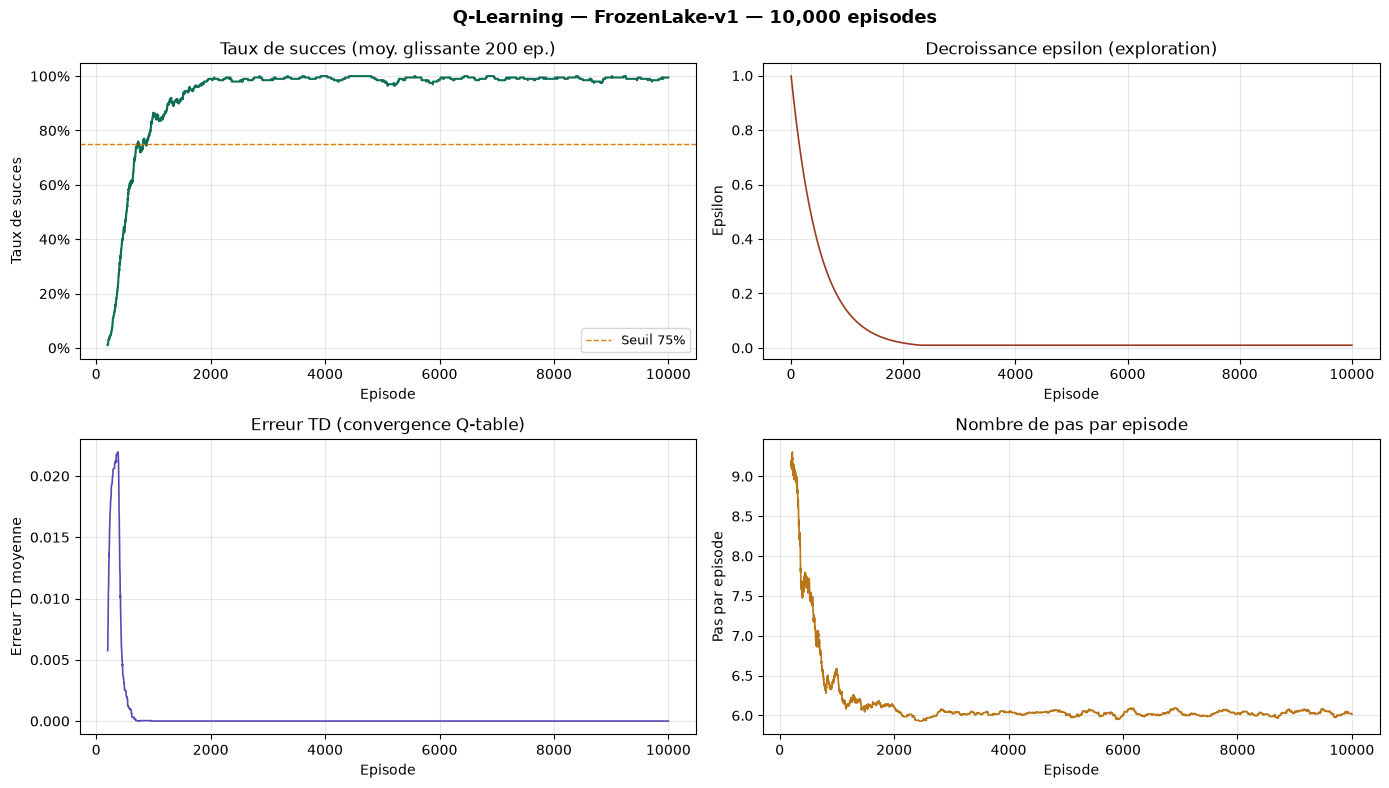

In [6]:
# ============================================================
# COURBES D'APPRENTISSAGE — 4 graphiques
# ============================================================
WINDOW = 200  # fenetre moyenne glissante

fig_learning, axes = plt.subplots(2, 2, figsize=(14, 8))
fig_learning.suptitle(
    f'Q-Learning — FrozenLake-v1 — {N_EPISODES:,} episodes',
    fontsize=13, fontweight='bold')

episodes = np.arange(1, N_EPISODES + 1)

# ── Graphique 1 : taux de succes glissant ──────────────────
ax1 = axes[0, 0]
roll_success = moving_average(rewards_history, WINDOW)
ax1.plot(range(WINDOW, N_EPISODES + 1), roll_success,
         color='#0F6E56', linewidth=1.5)
ax1.axhline(0.75, color='#E07B00', lw=1, ls='--',
            label='Seuil 75%')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Taux de succes')
ax1.set_title(f'Taux de succes (moy. glissante {WINDOW} ep.)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Graphique 2 : decroissance epsilon ─────────────────────
ax2 = axes[0, 1]
ax2.plot(episodes, epsilon_history,
         color='#993C1D', linewidth=1.2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Epsilon')
ax2.set_title('Decroissance epsilon (exploration)')
ax2.grid(True, alpha=0.3)

# ── Graphique 3 : erreur TD ────────────────────────────────
ax3 = axes[1, 0]
roll_td = moving_average(td_errors, WINDOW)
ax3.plot(range(WINDOW, N_EPISODES + 1), roll_td,
         color='#534AB7', linewidth=1.2)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Erreur TD moyenne')
ax3.set_title('Erreur TD (convergence Q-table)')
ax3.grid(True, alpha=0.3)

# ── Graphique 4 : pas par episode ─────────────────────────
ax4 = axes[1, 1]
roll_steps = moving_average(steps_history, WINDOW)
ax4.plot(range(WINDOW, N_EPISODES + 1), roll_steps,
         color='#BA7517', linewidth=1.2)
ax4.set_xlabel('Episode')
ax4.set_ylabel('Pas par episode')
ax4.set_title('Nombre de pas par episode')
ax4.grid(True, alpha=0.3)

plt.tight_layout()

plt_learning_curves = plt
plt_learning_curves.show()

### Interpretation: Courbes d'apprentissage

- **Taux de succes** : doit monter de ~0% vers 70-80% apres convergence
- **Epsilon** : decroit lineairement de 1.0 vers 0.01 — l'agent explore de moins en moins
- **Erreur TD** : doit diminuer — la Q-table converge vers les vraies valeurs
- **Pas par episode** : peut augmenter puis stabiliser — l'agent trouve des chemins plus efficaces

> **Note :** `is_slippery=True` (defaut) rend la convergence difficile.
> Taux de succes de 70-75% est excellent dans ce cas.

---
### [Cellule] 🏁 Visualisation. Q-table heatmap

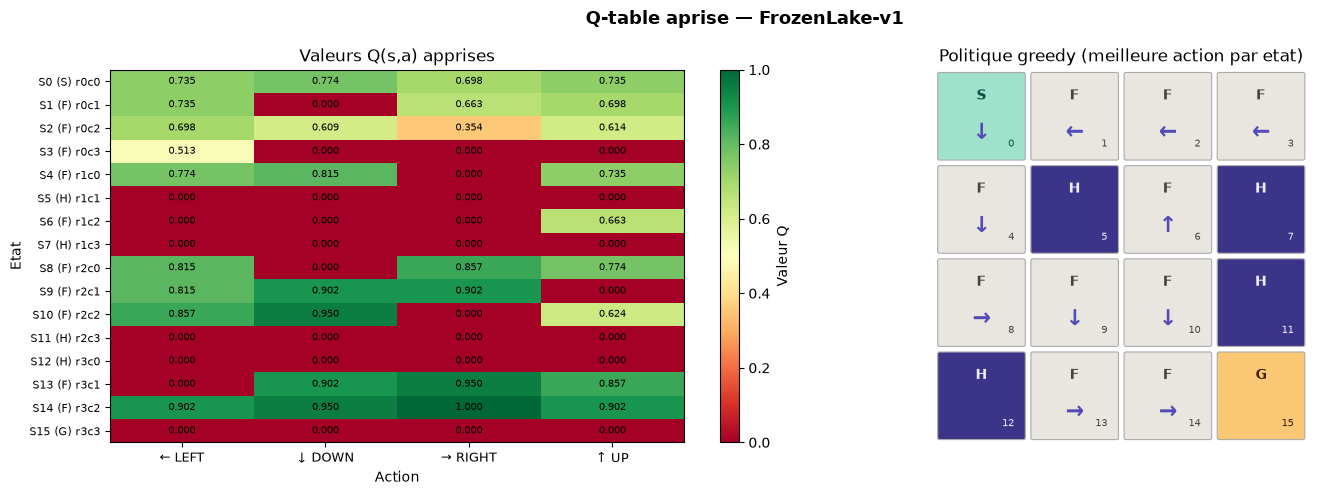

In [7]:
# ============================================================
# Q-TABLE HEATMAP — valeurs apprises
# ============================================================
ACTION_LABELS = ['← LEFT', '↓ DOWN', '→ RIGHT', '↑ UP']
GRID = ['S','F','F','F',
        'F','H','F','H',
        'F','F','F','H',
        'H','F','F','G']

fig_heatmap, axes = plt.subplots(1, 2, figsize=(15, 5))
fig_heatmap.suptitle('Q-table aprise — FrozenLake-v1', fontsize=13, fontweight='bold')

# ── Heatmap valeurs Q ──────────────────────────────────────
ax1 = axes[0]
im = ax1.imshow(q_table, cmap='RdYlGn', aspect='auto')
ax1.set_xticks(range(n_actions))
ax1.set_xticklabels(ACTION_LABELS, fontsize=9)
ax1.set_yticks(range(n_states))
ax1.set_yticklabels(
    [f'S{i} ({GRID[i]}) r{i//4}c{i%4}' for i in range(n_states)],
    fontsize=8)
ax1.set_xlabel('Action')
ax1.set_ylabel('Etat')
ax1.set_title('Valeurs Q(s,a) apprises')
plt.colorbar(im, ax=ax1, label='Valeur Q')
for i in range(n_states):
    for j in range(n_actions):
        ax1.text(j, i, f'{q_table[i,j]:.3f}',
                 ha='center', va='center', fontsize=7,
                 color='black')

# ── Grille politique greedy ────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 4)
ax2.set_ylim(0, 4)
ax2.set_aspect('equal')
ax2.set_title('Politique greedy (meilleure action par etat)')
ax2.axis('off')

COLORS = {'S':'#9FE1CB','F':'#E8E6DF','H':'#3C3489','G':'#FAC775'}
TCOLORS= {'S':'#085041','F':'#444441','H':'#EEEDFE','G':'#412402'}
ARR    = {0:'←', 1:'↓', 2:'→', 3:'↑'}

for state in range(n_states):
    row = state // 4
    col = state  % 4
    tile = GRID[state]
    x, y = col, 3 - row   # inverser y pour afficher ligne 0 en haut
    rect = patches.FancyBboxPatch(
        (x+0.05, y+0.05), 0.90, 0.90,
        boxstyle='round,pad=0.02',
        facecolor=COLORS[tile], edgecolor='#AAAAAA', lw=0.8)
    ax2.add_patch(rect)
    ax2.text(x+0.5, y+0.72, tile, ha='center', va='center',
             fontsize=10, fontweight='bold', color=TCOLORS[tile])
    ax2.text(x+0.85, y+0.15, str(state), ha='right', va='bottom',
             fontsize=7, color=TCOLORS[tile])
    if tile not in ('H', 'G'):
        best_action = np.argmax(q_table[state, :])
        ax2.text(x+0.5, y+0.32, ARR[best_action],
                 ha='center', va='center',
                 fontsize=16, color='#534AB7', fontweight='bold')

plt.tight_layout()

plt_heatmap = plt
# plt.show()



### [Cellule] 🏁 Visualisation. ⭐ Q-Directional Map 

**⭐⭐⭐ NOTE METHODOLOGIQUE ⭐⭐⭐**

**Nouveau outil de visualisation**

* Après recherche et consultation de la bibliographie standard en RL (et des documentations web, ia, papers, etc), aucun graphique similaire n'a été répertorié. 
* **Cette implémentation est proposée comme une contribution originale.**
* Cette fonction introduit une approche inédite pour visualiser l'apprentissage par renforcement : elle cartographie graphiquement la convergence de la Q-table  sous forme de vecteurs directionnels. 
        

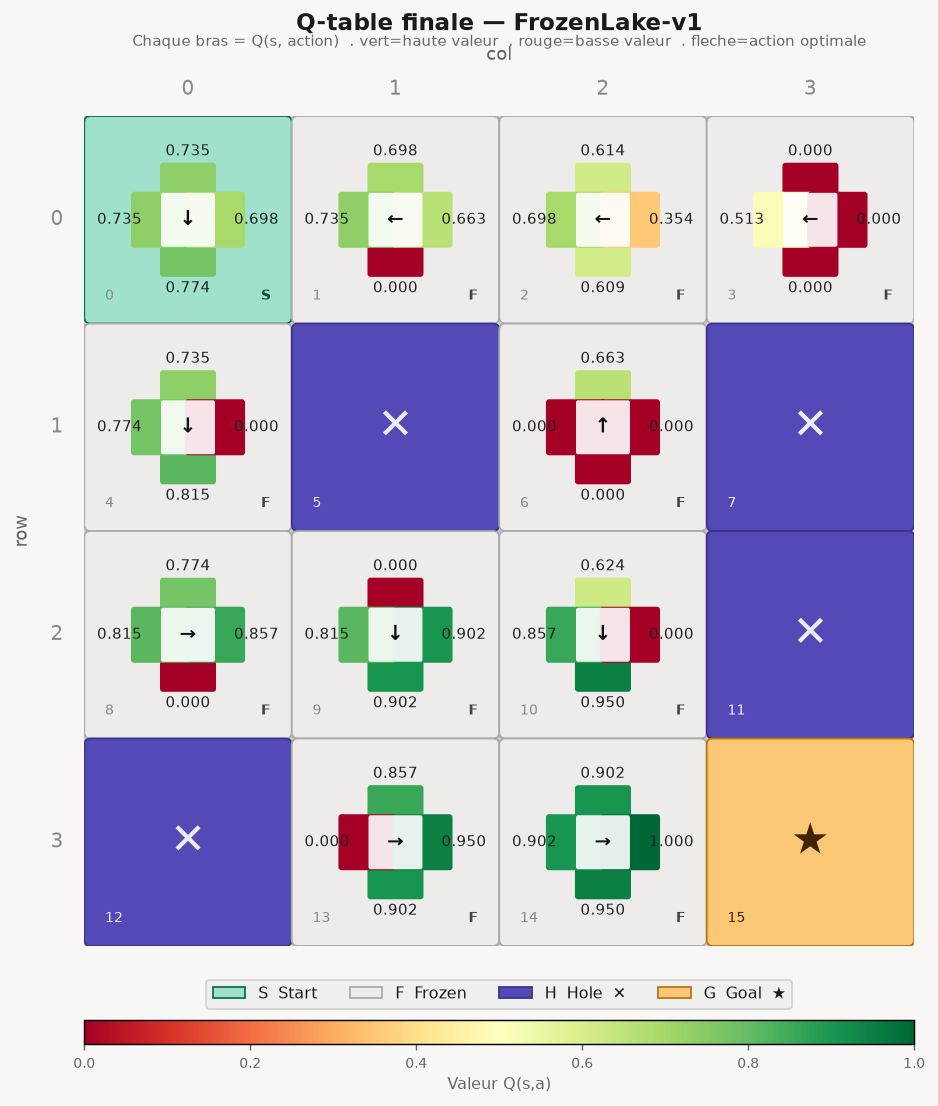

In [8]:
# ── Carte directionnelle Q — affichage ──────────

fig_q_directional_map = plot_q_directional_map(
    q_table,
    title = f"Q-table finale — FrozenLake-v1",
    dark  = False)

display(fig_q_directional_map)
plt.close(fig_q_directional_map)

---
## Etape 3. Evaluation de l'agent entraine

Phase d'evaluation : **epsilon = 0** (pure exploitation, pas d'exploration).
La Q-table est **gelee** — aucune mise a jour des poids.

### [Cellule] 🔍 Evaluation 

In [9]:
# ============================================================
# DIAGNOSTICO COMPLETO
# ============================================================
env_diag = make_env('FrozenLake-v1', seed=42)
state, _ = env_diag.reset()

print(f"Estado inicial : {state}")
print(f"Q-values estado {state} : {q_table[state]}")
print(f"Mejor accion   : {np.argmax(q_table[state])}  "
      f"({'←↓→↑'[np.argmax(q_table[state])]})")
print()

for paso in range(15):
    action = np.argmax(q_table[state, :])
    state, reward, terminated, truncated, _ = env_diag.step(action)
    print(f"  paso {paso+1:2d} → accion {'←↓→↑'[action]}  "
          f"estado {state:2d}  reward {reward}  "
          f"terminated={terminated}  truncated={truncated}")
    if terminated or truncated:
        break

env_diag.close()

Estado inicial : 0
Q-values estado 0 : [0.73509189 0.77378094 0.6983373  0.73509189]
Mejor accion   : 1  (↓)

  paso  1 → accion ↓  estado  1  reward 0  terminated=False  truncated=False
  paso  2 → accion ←  estado  5  reward 0  terminated=True  truncated=False


In [10]:
# Comparar slippery vs deterministe
print("\n=== is_slippery=True (defaut) ===")
wins = 0
env_s = gym.make('FrozenLake-v1')
for _ in range(1000):
    s, _ = env_s.reset()
    done = trunc = False
    while not (done or trunc):
        s, r, done, trunc, _ = env_s.step(np.argmax(q_table[s]))
    wins += r
env_s.close()
print(f"Taux de succes (1000 ep) : {wins/1000:.1%}")

print("\n=== is_slippery=False ===")
wins = 0
env_d = gym.make('FrozenLake-v1', is_slippery=False)
for _ in range(1000):
    s, _ = env_d.reset()
    done = trunc = False
    while not (done or trunc):
        s, r, done, trunc, _ = env_d.step(np.argmax(q_table[s]))
    wins += r
env_d.close()
print(f"Taux de succes (1000 ep) : {wins/1000:.1%}")


=== is_slippery=True (defaut) ===
Taux de succes (1000 ep) : 4.0%

=== is_slippery=False ===
Taux de succes (1000 ep) : 100.0%


In [11]:
# ============================================================
# EVALUATION — 100 episodes avec epsilon = 0
# ============================================================
N_EVAL   = 100
env_eval = make_env('FrozenLake-v1', seed=99, is_slippery=IS_SLIPPERY)

eval_rewards = []
eval_steps   = []

for ep in range(N_EVAL):
    # ✅ env_eval (pas env) + pas de seed fixe
    state, _     = env_eval.reset()
    total_reward = 0.0
    n_steps      = 0
    terminated   = False
    truncated    = False

    while not (terminated or truncated):
        # Toujours la meilleure action connue (epsilon = 0)
        action                              = np.argmax(q_table[state, :])
        # ✅ env_eval partout
        state, reward, terminated, truncated, _ = env_eval.step(action)
        total_reward += reward
        n_steps      += 1

    eval_rewards.append(total_reward)
    eval_steps.append(n_steps)

env_eval.close()



# Statistiques
stats = compute_stats(eval_rewards, eval_steps)
print_stats(stats, label='Evaluation Q-Learning -- 100 episodes -- FrozenLake-v1')
taux = success_rate(eval_rewards, threshold=1.0)


reward_finale = np.mean(eval_rewards)

nom_exercice  = f"ex2_{ts}_frozenlake_{taux:.0%}" 
print(f'  nom_exercice........: {nom_exercice}')
print(f'  Taux de succes.......: {taux:.1%}')
print()
if taux >= 0.70:
    print('SUCCES : taux >= 70% -- agent competent sur FrozenLake')
elif taux >= 0.50:
    print('PARTIEL : taux >= 50% -- apprentissage visible, ajuster hyperparametres')
else:
    print('A AMELIORER : taux < 50% -- augmenter N_EPISODES ou ajuster alpha/gamma')




  Evaluation Q-Learning -- 100 episodes -- FrozenLake-v1
  Episodes............: 100
  Recompense moyenne..:    1.00  +-  0.00
  Recompense min/max..:    1.00  /   1.00
  Mediane.............:    1.00
  Q25 / Q75...........:    1.00  /   1.00
  Pas moyens..........:     6.0  +-  0.0
  Pas maximum.........:       6
  nom_exercice........: ex2_260620_113758_frozenlake_100%
  Taux de succes.......: 100.0%

SUCCES : taux >= 70% -- agent competent sur FrozenLake


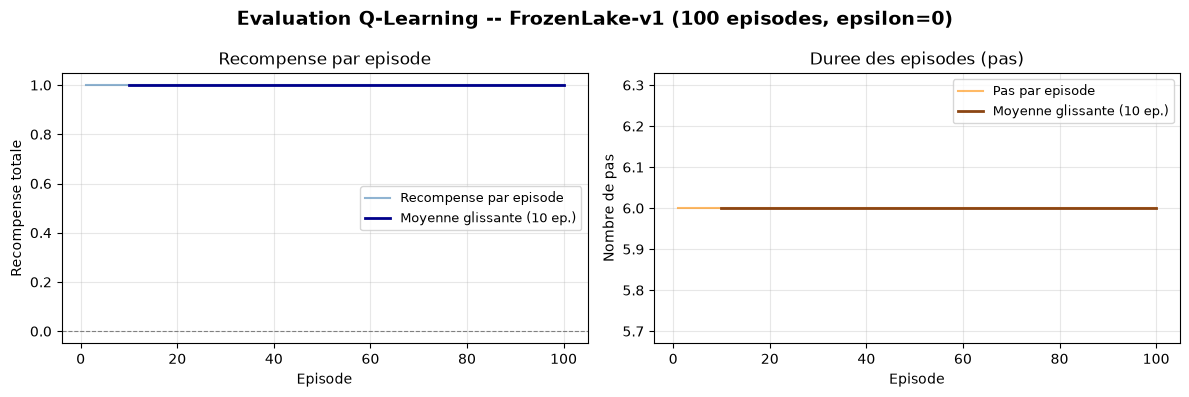

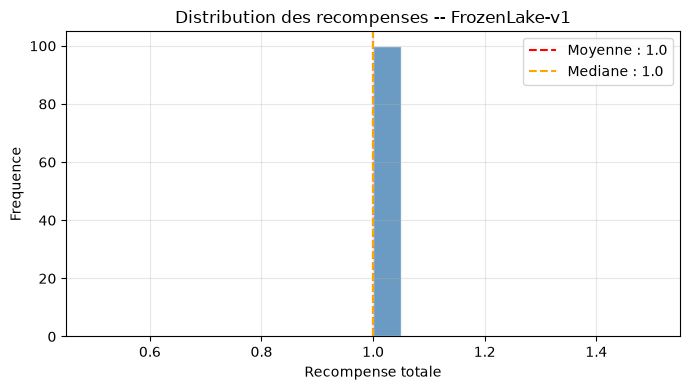

In [12]:
# Graphiques evaluation
plot_episode_metrics(
    eval_rewards, eval_steps,
    title='Evaluation Q-Learning -- FrozenLake-v1 (100 episodes, epsilon=0)'
)
plot_reward_distribution(eval_rewards, env_id='FrozenLake-v1')

---
### [Cellule] 🎥 Animation agent entraine en temps reel

Animation cote a cote :
- **Gauche** : grille FrozenLake avec l'agent se deplacant case par case
- **Droite haut** : recompense cumulee en temps reel
- **Droite bas** : Q-valeurs de l'etat courant (bar chart mis a jour)

In [13]:
# ============================================================
# ANIMATION FROZENLAKE — agent + Q-values en temps reel
# ============================================================

def animate_frozenlake_agent(q_table, seed=42, max_steps=50):
    GRID = ['S','F','F','F',
            'F','H','F','H',
            'F','F','F','H',
            'H','F','F','G']
    COLORS  = {'S':'#9FE1CB','F':'#E8E6DF','H':'#3C3489','G':'#FAC775'}
    TCOLORS = {'S':'#085041','F':'#444441','H':'#EEEDFE','G':'#412402'}
    ACTION_ARR = {0:'←', 1:'↓', 2:'→', 3:'↑'}
    ACTION_COL = ['#0F6E56','#993C1D','#534AB7','#BA7517']

    # Collecter la trajectoire
    # env_anim = gym.make('FrozenLake-v1', render_mode=None)
    env_anim = gym.make('FrozenLake-v1', is_slippery=IS_SLIPPERY , render_mode=None)
    state, _ = env_anim.reset(seed=seed)
    trajectory   = [state]
    actions_taken= []
    rewards_cum  = [0.0]
    q_vals_seq   = [q_table[state].copy()]
    terminated = truncated = False
    step = 0
    while not (terminated or truncated) and step < max_steps:
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, _ = env_anim.step(action)
        trajectory.append(state)
        actions_taken.append(action)
        rewards_cum.append(rewards_cum[-1] + reward)
        q_vals_seq.append(q_table[state].copy())
        step += 1
    env_anim.close()

    T = len(trajectory)

    # Construire la figure
    fig = plt.figure(figsize=(14, 5))
    fig.patch.set_facecolor('#F8F7F5')
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1],
                           height_ratios=[1, 1], figure=fig,
                           hspace=0.45, wspace=0.35)
    ax_grid = fig.add_subplot(gs[:, 0])  # grille (colonne gauche entiere)
    ax_rew  = fig.add_subplot(gs[0, 1])  # recompense (droite haut)
    ax_qval = fig.add_subplot(gs[1, 1])  # Q-values (droite bas)

    fig.suptitle('FrozenLake-v1 — Agent Q-Learning en action', fontsize=12, fontweight='bold')

    # ── Dessiner la grille statique ──────────────────────────
    ax_grid.set_xlim(0, 4)
    ax_grid.set_ylim(0, 4)
    ax_grid.set_aspect('equal')
    ax_grid.axis('off')
    ax_grid.set_facecolor('#F8F7F5')

    tile_patches = {}
    for s in range(16):
        r, c = s//4, s%4
        tile  = GRID[s]
        x, y  = c, 3 - r
        rect = patches.FancyBboxPatch(
            (x+0.04, y+0.04), 0.92, 0.92,
            boxstyle='round,pad=0.02',
            facecolor=COLORS[tile], edgecolor='#CCCCCC', lw=0.8)
        ax_grid.add_patch(rect)
        tile_patches[s] = rect
        ax_grid.text(x+0.5, y+0.72, tile, ha='center', va='center',
                     fontsize=11, fontweight='bold', color=TCOLORS[tile])
        ax_grid.text(x+0.88, y+0.12, str(s), ha='right', va='bottom',
                     fontsize=7, color=TCOLORS[tile])

    # Agent marker
    agent_circ = plt.Circle((0.5, 3.5), 0.22,
                             facecolor='#534AB7', edgecolor='#26215C',
                             lw=1.2, zorder=5)
    ax_grid.add_patch(agent_circ)
    agent_txt  = ax_grid.text(0.5, 3.5, 'A', ha='center', va='center',
                               fontsize=10, fontweight='bold',
                               color='#EEEDFE', zorder=6)
    step_txt   = ax_grid.text(2.0, -0.25, '',
                               ha='center', va='center',
                               fontsize=9, color='#555555')

    # ── Recompense ────────────────────────────────────────────
    line_rew, = ax_rew.plot([], [], color='#0F6E56', lw=2)
    pt_rew,   = ax_rew.plot([], [], 'o', color='#0F6E56', ms=6)
    ax_rew.set_xlim(0, T)
    ax_rew.set_ylim(-0.1, 1.2)
    ax_rew.axhline(1.0, color='#BA7517', lw=0.8, ls='--', label='Goal')
    ax_rew.set_xlabel('Pas', fontsize=9)
    ax_rew.set_ylabel('Recompense cumulee', fontsize=9)
    ax_rew.set_title('Recompense', fontsize=10)
    ax_rew.grid(True, alpha=0.3)

    # ── Q-values bar chart ────────────────────────────────────
    bars = ax_qval.bar(['← 0','↓ 1','→ 2','↑ 3'],
                       [0,0,0,0], color=ACTION_COL, alpha=0.8)
    ax_qval.set_ylim(-0.05, 1.05)
    ax_qval.set_ylabel('Q-valeur', fontsize=9)
    ax_qval.set_title('Q-valeurs etat courant', fontsize=10)
    ax_qval.grid(True, alpha=0.3, axis='y')
    best_marker = ax_qval.axhline(0, color='red', lw=1, ls='--', alpha=0.5)

    # plt.tight_layout()
    plt.subplots_adjust(left=0.05, right=0.97,
                    top=0.88,  bottom=0.10,
                    hspace=0.45, wspace=0.35)
    
    # Taille par défaut des figures
    # plt.rcParams['figure.figsize']  = (12, 5)
    # plt.rcParams['figure.dpi']      = 80       # ← réduire si lent
    # plt.rcParams['animation.embed_limit'] = 50  # Mo max pour HTML

    print(f"Backend matplotlib : {matplotlib.get_backend()}")

    def update(frame):
        i = min(frame, T - 1)
        s = trajectory[i]
        r, c = s // 4, s % 4
        x, y = c + 0.5, 3 - r + 0.5

        # Deplacer l'agent
        agent_circ.center = (x, y)
        agent_txt.set_position((x, y))

        # Mettre en evidence la case courante
        for st, patch in tile_patches.items():
            patch.set_linewidth(0.8)
            patch.set_edgecolor('#CCCCCC')
        tile_patches[s].set_edgecolor('#534AB7')
        tile_patches[s].set_linewidth(2.5)

        # Texte action
        if i < len(actions_taken):
            a = actions_taken[i]
            step_txt.set_text(f'Pas {i+1}/{T-1}  |  action: {ACTION_ARR[a]}  |  reward: {rewards_cum[i]:.1f}')
        else:
            outcome = 'VICTOIRE' if rewards_cum[-1] > 0 else 'ECHEC'
            step_txt.set_text(f'{outcome}  |  reward final: {rewards_cum[-1]:.1f}')

        # Courbe recompense
        xs = list(range(i + 1))
        ys = rewards_cum[:i + 1]
        line_rew.set_data(xs, ys)
        pt_rew.set_data([xs[-1]], [ys[-1]])

        # Q-values
        qv = q_vals_seq[i]
        for bar, v in zip(bars, qv):
            bar.set_height(max(v, 0))
        best_v = max(qv)
        best_marker.set_ydata([best_v, best_v])

        return [agent_circ, agent_txt, step_txt,
                line_rew, pt_rew, best_marker] + list(bars)

    anim = animation.FuncAnimation(
        fig, update, frames=T,
        interval=600, blit=True, repeat=True)

    # Opción C — reducir frames de la animación
    #anim = animation.FuncAnimation(
    #    fig, update,
    #    frames=range(0, T, 2),  # ← saltar 1 frame de cada 2
    #    interval=40, blit=True)

    plt.close()
    
    # return HTML(anim.to_jshtml())
    # return HTML(anim.to_html5_video())
    return anim
    


# Lancer l'animation
anim      = animate_frozenlake_agent(q_table, seed=42)
anim_html = HTML(anim.to_html5_video())

display(anim_html)


Backend matplotlib : inline


### [Cellule] 💾 Animation. Sauvegarder 

In [14]:
# ── Sauvegarder la vidéo — Exercice 2 FrozenLake ─────────────
# nom_anim      = f"ex2_frozenlake_{taux:.0%}_succes" 

anim_path_mp4  = MODELS / f"{nom_exercice}.mp4"
anim_path_gif = MODELS / f"{nom_exercice}.gif"


try:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter(fps=30, bitrate=1800)
    anim.save(str(anim_path_mp4), writer=writer)
    print(f"  MP4 sauvegardé.....: {anim_path_mp4.name}")
    print(f"  Taille..............: "
          f"{anim_path_mp4.stat().st_size // 1024} KB")
except Exception as e:
    from matplotlib.animation import PillowWriter
    print(f"  FFMpeg non disponible : {e}")
    writer = PillowWriter(fps=25)
    anim.save(str(anim_path_gif), writer=writer)
    print(f"  GIF sauvegardé.....: {anim_path_gif.name}")
    print(f"  Taille..............: "
          f"{anim_path_gif.stat().st_size // 1024} KB")

  MP4 sauvegardé.....: ex2_260620_113758_frozenlake_100%.mp4
  Taille..............: 22 KB


### [Cellule] 💾 Sauvegarder Q-TABLE

In [15]:
# ============================================================
# SAUVEGARDER Q-TABLE — FrozenLake + métadonnées
# ============================================================
import json
import pickle

# ── Convertir numpy types → Python natifs ────────────────────
def to_serializable(obj):
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    return obj
    


# ── Sauvegarder learning_curves ──────────────────────────────
fig_path = MODELS / f"{nom_exercice}_learning_curves.png"
fig_learning.savefig(str(fig_path), dpi=120, bbox_inches='tight')
print(f"  Figure sauvegardée..: {fig_path.name}")

# ── Sauvegarder le heatmap ────────────────────────────────────
plt_heatmap_path = MODELS / f"{nom_exercice}_heatmap.png"
fig_heatmap.savefig(str(plt_heatmap_path), dpi=120, bbox_inches='tight')
print(f"  Heatmap sauvegardé..: {plt_heatmap_path.name}")


# ── Carte directionnelle Q — sauvegarde ──────────────────────
fig_q_directional_map_path = MODELS / f"{nom_exercice}_directional_map.png"

fig_q_directional_map.savefig(
    str(fig_q_directional_map_path),
    dpi         = 120,
    bbox_inches = 'tight',
    facecolor   = fig_q_directional_map.get_facecolor())  # ← fig, pas path

print(f"  Carte Q sauvegardée.: {fig_q_directional_map_path.name}")


# ── Nom du fichier avec score ─────────────────────────────────

qtable_pkl_path  = MODELS / f"{nom_exercice}_q_table.pkl"
qtable_meta_path = MODELS / f"{nom_exercice}_q_table_meta.json"

# ── Sauvegarder la Q-table ────────────────────────────────────
# q_path = MODELS / 'ex2_q_table_frozenlake.pkl'      # Q-table FrozenLake sauvegardée
# q_path = MODELS / f"{nom_exercice}_q_table.pkl"

with open(qtable_pkl_path, 'wb') as f:
    pickle.dump(q_table, f)

# ── Métadonnées ───────────────────────────────────────────────
metadata = {
    # ── Résultats ─────────────────────────────────────────────
    "reward_finale"    : round(float(reward_finale), 3),
    "taux_succes"      : round(float(taux), 3),
    "n_eval_episodes"  : int(N_EVAL),

    # ── Hyperparamètres Q-Learning ────────────────────────────
    "N_EPISODES"       : int(N_EPISODES),
    "ALPHA"            : float(ALPHA),             # learning rate Q-Learning
    "GAMMA"            : float(GAMMA),             # facteur de discount
    "EPSILON"          : float(EPSILON),           # epsilon initial
    "EPSILON_MIN"      : float(EPSILON_MIN),       # epsilon minimum
    "EPSILON_DEC"      : round(float(EPSILON_DEC), 6), # décroissance epsilon

    # ── Environnement ─────────────────────────────────────────
    "env_id"           : "FrozenLake-v1",
    "is_slippery"      : bool(IS_SLIPPERY),
    "n_states"         : int(n_states),
    "n_actions"        : int(n_actions),

    # ── Q-table ───────────────────────────────────────────────
    "q_table_shape"    : list(q_table.shape),
    "q_table_sum"      : round(float(q_table.sum()), 4),
    "q_table_max"      : round(float(q_table.max()), 4),
}
metadata = {k: to_serializable(v) for k, v in metadata.items()}

with open(qtable_meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

# ── Vérification ──────────────────────────────────────────────
print("\n============================================================")
print("SAUVEGARDE Q-TABLE FROZENLAKE")
print("============================================================")
print(f"  Fichier Q-table.....: {qtable_pkl_path.name}")
print(f"  Taille..............: "
      f"{qtable_pkl_path.stat().st_size} octets")
print(f"  Fichier meta........: {qtable_meta_path.name}")
print(f"  Reward finale.......: {reward_finale:.3f}")
print(f"  Taux de succès......: {taux:.1%}")
print(f"  Q-table sum.........: {q_table.sum():.4f}")
print(f"  Q-table max.........: {q_table.max():.4f}")
print(f"  Chemin complet......: {qtable_pkl_path}")
print("============================================================")


  Figure sauvegardée..: ex2_260620_113758_frozenlake_100%_learning_curves.png
  Heatmap sauvegardé..: ex2_260620_113758_frozenlake_100%_heatmap.png
  Carte Q sauvegardée.: ex2_260620_113758_frozenlake_100%_directional_map.png

SAUVEGARDE Q-TABLE FROZENLAKE
  Fichier Q-table.....: ex2_260620_113758_frozenlake_100%_q_table.pkl
  Taille..............: 665 octets
  Fichier meta........: ex2_260620_113758_frozenlake_100%_q_table_meta.json
  Reward finale.......: 1.000
  Taux de succès......: 100.0%
  Q-table sum.........: 24.7768
  Q-table max.........: 1.0000
  Chemin complet......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\ex2_260620_113758_frozenlake_100%_q_table.pkl


---
## Conclusion. Exercice 2

**Ce que nous avons appris :**

1. **Q-table** : matrice `(n_etats x n_actions)` initialisee a zero,
   mise a jour par l'equation de Bellman

2. **Equation de Bellman** :
```
Q(s,a) <- Q(s,a) + alpha * [R + gamma * max Q(s',a') - Q(s,a)]
```

3. **Epsilon-greedy (GLIE)** : exploration decroissante pour garantir
   convergence vers la politique optimale

4. **Evaluation** : phase separee avec epsilon=0 — la Q-table est gelee

5. **Limite** : Q-table impossible pour CartPole (espace continu infini)
   → DQN (reseau neuronal) dans l'Exercice 3

**Comparaison :**

| Metrique | Politique aleatoire (Ex.1) | Q-Learning (Ex.2) |
|---|---|---|
| Taux de succes | ~0% | ~70-80% |
| Strategie | Aucune | Bellman + epsilon-greedy |
| Memoire | Aucune | Q-table (16x4 = 64 valeurs) |

**Prochaine etape :** Exercice 3 — DQN (reseau neuronal) sur CartPole-v1